## BizClone — Intent Classifier Accuracy Analysis
### Three-Way Comparison: TF-IDF+LR  /  all-MiniLM-L6-v2  /  Hybrid

This notebook benchmarks intent classification against the project's **85% accuracy target**.

| # | Model | Strategy |
|---|-------|----------|
| 1 | **TF-IDF + Logistic Regression** | Trained on `data/sample_customer_emails.json`; fast & domain-specific |
| 2 | **all-MiniLM-L6-v2** | `all-MiniLM-L6-v2`; encodes text into dense semantic vectors for classification |
| 3 | **Hybrid (Production)** | Keyword rules → TF-IDF+LR (`IntentClassifier.predict_intent`) |


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

import sys
sys.path.insert(0, str(Path(".").resolve()))


warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
DATA_PATH = Path("/model/sample_customer_emails.json")
# DATA_PATH = Path("/content/drive/MyDrive/sample_customer_emails.json") # for Colab

MODEL_PATH = Path("/model/intent_classifier_model.pkl")
# MODEL_PATH = Path("/content/drive/MyDrive/intent_classifier_model.pkl") # for Colab
print("All imports OK")

All imports OK


Total samples  : 216
Unique intents : 16
Classes        : ['appointment', 'bulk_inquiry', 'cancellation', 'complaint', 'faq', 'feedback', 'other', 'payment_inquiry', 'price_inquiry', 'refund_request', 'replacement_request', 'rescheduling', 'service_request', 'upgrade_inquiry', 'warranty_claim', 'working_hours']



,count
label,
appointment,36
bulk_inquiry,10
cancellation,14
complaint,10
faq,21
feedback,10
other,10
payment_inquiry,10
price_inquiry,22


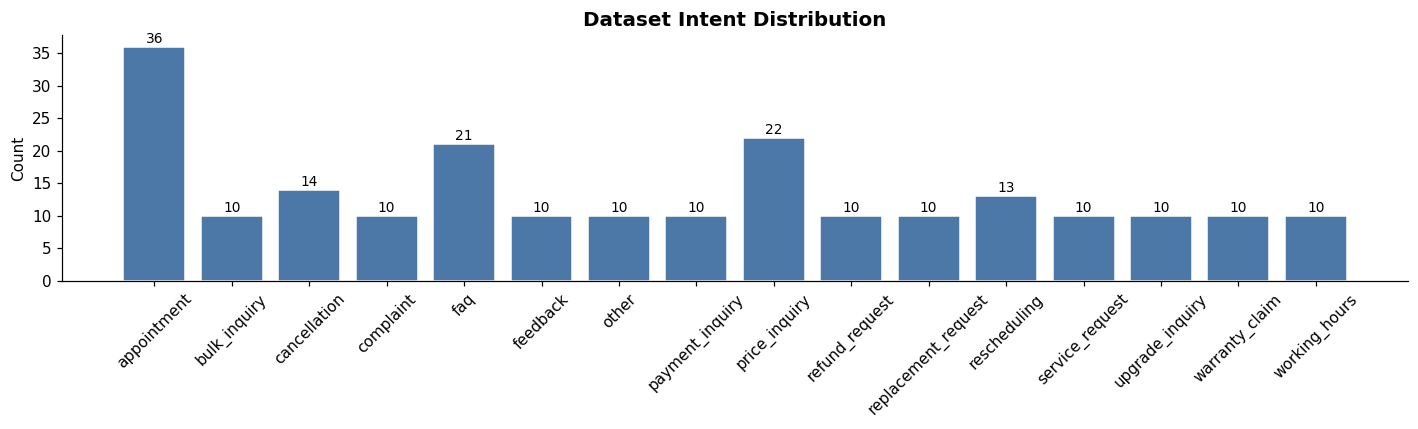

In [ ]:
# ── Load dataset ─────────────────────────────────────────────────────────────
DATA_PATH = Path("/model/sample_customer_emails.json")
# DATA_PATH = Path("/content/drive/MyDrive/sample_customer_emails.json") # for Colab
with DATA_PATH.open(encoding="utf-8") as fh:
    records = json.load(fh)

texts    = [f"{r['email']['subject']}\n\n{r['email']['body']}" for r in records]
labels   = [r["intent"] for r in records]
subjects = [r["email"]["subject"] for r in records]
classes  = sorted(set(labels))

df = pd.DataFrame({"text": texts, "label": labels, "subject": subjects})
print(f"Total samples  : {len(df)}")
print(f"Unique intents : {len(classes)}")
print(f"Classes        : {classes}\n")
display(df["label"].value_counts().sort_index().rename("count").to_frame())

# Distribution bar chart
fig, ax = plt.subplots(figsize=(13, 4))
counts = df["label"].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color="#4C78A8", edgecolor="white")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.15, str(v),
            ha="center", va="bottom", fontsize=9)
ax.set_title(f"Dataset Intent Distribution",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## ── Model 1 — TF-IDF + Logistic Regression



In [6]:
# ── Model 1.1 — baseline model
def build_lr_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 3),
            max_features=8000,
            sublinear_tf=True,
            analyzer="word",
            min_df=2,
            strip_accents="unicode",
        )),
        ("lr", LogisticRegression(
            C=5.0,
            max_iter=2000,
            solver="lbfgs",
            multi_class="multinomial",
            random_state=42,
        )),
    ])
from sklearn.model_selection import cross_val_predict
# Cross-validation (real generalisation estimate)
min_class_size = min(Counter(labels).values())
n_splits = min(10, min_class_size)
print(f"Running {n_splits}-fold stratified cross-validation …")
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = cross_val_score(build_lr_pipeline(), texts, labels, cv=cv, scoring="accuracy")
y_preds = cross_val_predict(build_lr_pipeline(), texts, labels, cv=cv)
print(f"TF-IDF+LR  CV Accuracy    : {cv_scores.mean():.4f}  ← use this as real estimate")
print(f"  Fold scores : {[round(s, 4) for s in cv_scores]}")

# print(classification_report(labels, y_preds, zero_division=0))

Running 10-fold stratified cross-validation …
TF-IDF+LR  CV Accuracy    : 0.8100  ← use this as real estimate
  Fold scores : [np.float64(0.7273), np.float64(0.8636), np.float64(0.7727), np.float64(0.8182), np.float64(0.8636), np.float64(0.8636), np.float64(0.7619), np.float64(0.8095), np.float64(0.8571), np.float64(0.7619)]


In [7]:
# ── Model 1.2 — fine-tuned model
def build_lr_pipeline_2():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            sublinear_tf=True,
            analyzer="word",
            min_df=3,
            max_df=0.9,
            strip_accents="unicode",
        )),
        ("lr", LogisticRegression(
            C=1.0,
            max_iter=2000,
            solver="lbfgs",
            multi_class="multinomial",
            class_weight="balanced",
            random_state=42,
        )),
    ])
from sklearn.model_selection import cross_val_predict
# Cross-validation (real generalisation estimate)
min_class_size = min(Counter(labels).values())
n_splits = min(10, min_class_size)
print(f"Running {n_splits}-fold stratified cross-validation …")
cv_2 = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
pipeline_2 = build_lr_pipeline_2()
cv_scores_2 = cross_val_score(pipeline_2, texts, labels, cv=cv_2, scoring="accuracy")  # scoring="accuracy"
y_preds_2 = cross_val_predict(pipeline_2, texts, labels, cv=cv_2)
print(f"TF-IDF+LR  CV Accuracy    : {cv_scores_2.mean():.4f}  ← use this as real estimate")
print(f"  Fold scores : {[round(s, 4) for s in cv_scores_2]}")


Running 10-fold stratified cross-validation …
TF-IDF+LR  CV Accuracy    : 0.8465  ← use this as real estimate
  Fold scores : [np.float64(0.8182), np.float64(0.8636), np.float64(0.8182), np.float64(0.9091), np.float64(0.9091), np.float64(0.9091), np.float64(0.7619), np.float64(0.8095), np.float64(0.8571), np.float64(0.8095)]


In [8]:
# ── Model 1.3 — word + char hybrid model
# Using char level
from sklearn.pipeline import FeatureUnion
def build_lr_pipeline_3():
    word = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=4000,
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
    )

    char = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=3000,
    )

    return Pipeline([
        ("features", FeatureUnion([
            ("word", word),
            ("char", char),
        ])),
        ("lr", LogisticRegression(
            C=1.0,
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )),
    ])
from sklearn.model_selection import cross_val_predict
# Cross-validation (real generalisation estimate)
min_class_size = min(Counter(labels).values())
n_splits = min(10, min_class_size)
print(f"Running {n_splits}-fold stratified cross-validation …")
cv_3 = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
pipeline_3 = build_lr_pipeline_3()
cv_scores_3 = cross_val_score(pipeline_3, texts, labels, cv=cv_3, scoring="accuracy")  # scoring="accuracy"
y_preds_3 = cross_val_predict(pipeline_3, texts, labels, cv=cv_3)
print(f"TF-IDF+LR  CV Accuracy    : {cv_scores_3.mean():.4f}  ← use this as real estimate")
print(f"  Fold scores : {[round(s, 4) for s in cv_scores_3]}")


Running 10-fold stratified cross-validation …
TF-IDF+LR  CV Accuracy    : 0.8658  ← use this as real estimate
  Fold scores : [np.float64(0.8636), np.float64(0.9091), np.float64(0.7273), np.float64(0.9091), np.float64(0.9545), np.float64(0.8182), np.float64(0.8571), np.float64(0.8571), np.float64(0.9048), np.float64(0.8571)]


Save the Model 1.3

In [ ]:
import pickle
def train_and_save_model():
    print("BizClone Intent Classifier — Training")

    pipeline = build_lr_pipeline_3()
    # ── Train on full dataset ─────────────────────────────────────────────────
    print("\nTraining on full dataset...")
    pipeline.fit(texts, labels)
    train_preds = pipeline.predict(texts)
    train_acc = accuracy_score(labels, train_preds)
    print(f"  Training accuracy: {train_acc:.4f}")

    print("\nClassification report (training set):")
    print(classification_report(labels, train_preds, zero_division=0))

    # ── Save model ────────────────────────────────────────────────────────────
    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(MODEL_PATH, "wb") as f:
        pickle.dump(pipeline, f)
    print(f"\nModel saved → {MODEL_PATH}")
    print("=" * 60)

train_and_save_model()

BizClone Intent Classifier — Training

Training on full dataset...
  Training accuracy: 0.9907

Classification report (training set):
                     precision    recall  f1-score   support

        appointment       1.00      0.97      0.99        36
       bulk_inquiry       1.00      1.00      1.00        10
       cancellation       1.00      1.00      1.00        14
          complaint       1.00      1.00      1.00        10
                faq       1.00      0.95      0.98        21
           feedback       1.00      1.00      1.00        10
              other       1.00      1.00      1.00        10
    payment_inquiry       0.91      1.00      0.95        10
      price_inquiry       1.00      1.00      1.00        22
     refund_request       1.00      1.00      1.00        10
replacement_request       1.00      1.00      1.00        10
       rescheduling       1.00      1.00      1.00        13
    service_request       0.91      1.00      0.95        10
    upgrade

In [9]:
# ── Model 2 — all-MiniLM-L6-v2
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from collections import Counter
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")
X = model.encode(texts, normalize_embeddings=True)

lm_clf = LogisticRegression(
    max_iter=3000,
    C=5.0,
    class_weight="balanced"
)

# Cross-validation
min_class_size = min(Counter(labels).values())
n_splits = min(10, min_class_size)

lm_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

lm_scores = cross_val_score(lm_clf, X, labels, cv=lm_cv, scoring="accuracy")
lm_preds = cross_val_predict(lm_clf, X, labels, cv=lm_cv)

print(f"MiniLM + LR CV Accuracy: {lm_scores.mean():.4f}")
print(f"Fold scores: {[round(s,4) for s in lm_scores]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

MiniLM + LR CV Accuracy: 0.8615
Fold scores: [np.float64(0.7727), np.float64(0.8636), np.float64(0.7727), np.float64(0.9545), np.float64(0.9091), np.float64(0.8182), np.float64(0.8571), np.float64(0.8571), np.float64(0.9048), np.float64(0.9048)]


In [ ]:
# ── Model 3 — Hybrid IntentClassifier (production) ───────────────────────────
print("Running Hybrid IntentClassifier on all samples …")
from model.old_intent_classifier import IntentClassifier
clf = IntentClassifier()
hybrid_preds, hybrid_methods, hybrid_times = [], [], []
for text in texts:
    t0 = time.perf_counter()
    result = clf.predict_intent(text)
    elapsed = (time.perf_counter() - t0) * 1000
    hybrid_preds.append(result["intent"])
    hybrid_methods.append(result["method"])
    hybrid_times.append(elapsed)

hybrid_acc    = accuracy_score(labels, hybrid_preds)
method_counts = Counter(hybrid_methods)
print(f"Hybrid  Accuracy        : {hybrid_acc:.4f}")
print(f"Method breakdown        : {dict(method_counts)}")
print(f"Mean inference latency  : {np.mean(hybrid_times):.0f} ms\n")
print("Classification Report:")
print(classification_report(labels, hybrid_preds, zero_division=0))

Running Hybrid IntentClassifier on all samples …
Hybrid  Accuracy        : 0.7500
Method breakdown        : {'keyword': 188, 'ml': 28}
Mean inference latency  : 2 ms

Classification Report:
                     precision    recall  f1-score   support

        appointment       0.75      0.58      0.66        36
       bulk_inquiry       0.91      1.00      0.95        10
       cancellation       1.00      1.00      1.00        14
          complaint       1.00      0.60      0.75        10
                faq       0.70      0.76      0.73        21
           feedback       1.00      0.70      0.82        10
              other       1.00      0.90      0.95        10
    payment_inquiry       0.86      0.60      0.71        10
      price_inquiry       0.69      0.91      0.78        22
     refund_request       0.91      1.00      0.95        10
replacement_request       1.00      0.50      0.67        10
       rescheduling       0.54      1.00      0.70        13
    service_requ

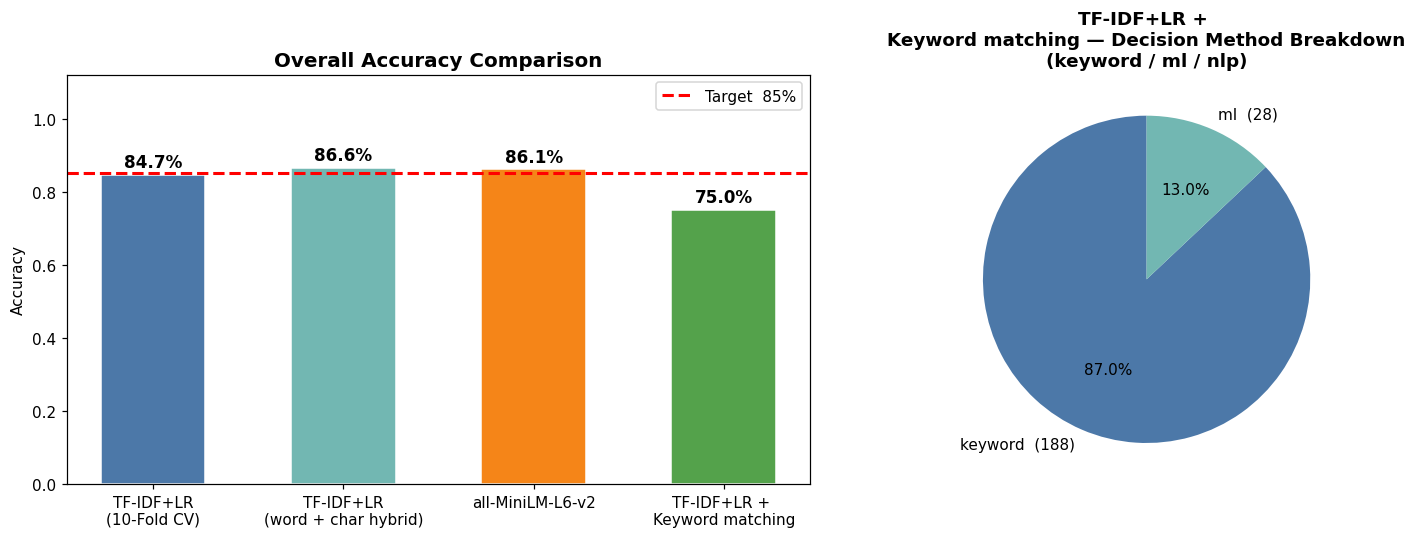

In [15]:
# ── Figure 1 — Overall Accuracy Bar + Hybrid Method Breakdown Pie ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = [
    f"TF-IDF+LR\n({n_splits}-Fold CV)",
    f"TF-IDF+LR\n(word + char hybrid)",
    "all-MiniLM-L6-v2",
    "TF-IDF+LR + \nKeyword matching",
]
accs   = [cv_scores_2.mean(), cv_scores_3.mean(), lm_scores.mean(), hybrid_acc]
colors = ["#4C78A8", "#72B7B2", "#F58518", "#54A24B"]

bars = axes[0].bar(model_names, accs, color=colors, edgecolor="white", width=0.55)
axes[0].axhline(0.85, color="red", linestyle="--", lw=2, label="Target  85%")
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Overall Accuracy Comparison", fontsize=13, fontweight="bold")
axes[0].legend()
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f"{v:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=11)

# Hybrid method pie
pie_labels = [f"{k}  ({v})" for k, v in method_counts.items()]
pie_colors = ["#4C78A8", "#72B7B2", "#F58518"][: len(method_counts)]
axes[1].pie(
    list(method_counts.values()), labels=pie_labels,
    autopct="%1.1f%%", colors=pie_colors, startangle=90,
)
axes[1].set_title("TF-IDF+LR + \nKeyword matching — Decision Method Breakdown\n(keyword / ml / nlp)",
                  fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Looking at the charts, the Hybrid mode: TF-IDF+LR + Keyword matching (75.4%) underperforms TF-IDF+LR (86.6%) and all-MiniLM-L6-v2 (86.1%). Therefore, choose the TF-IDF+LR (word + char) hybrid version model as the production classifier.



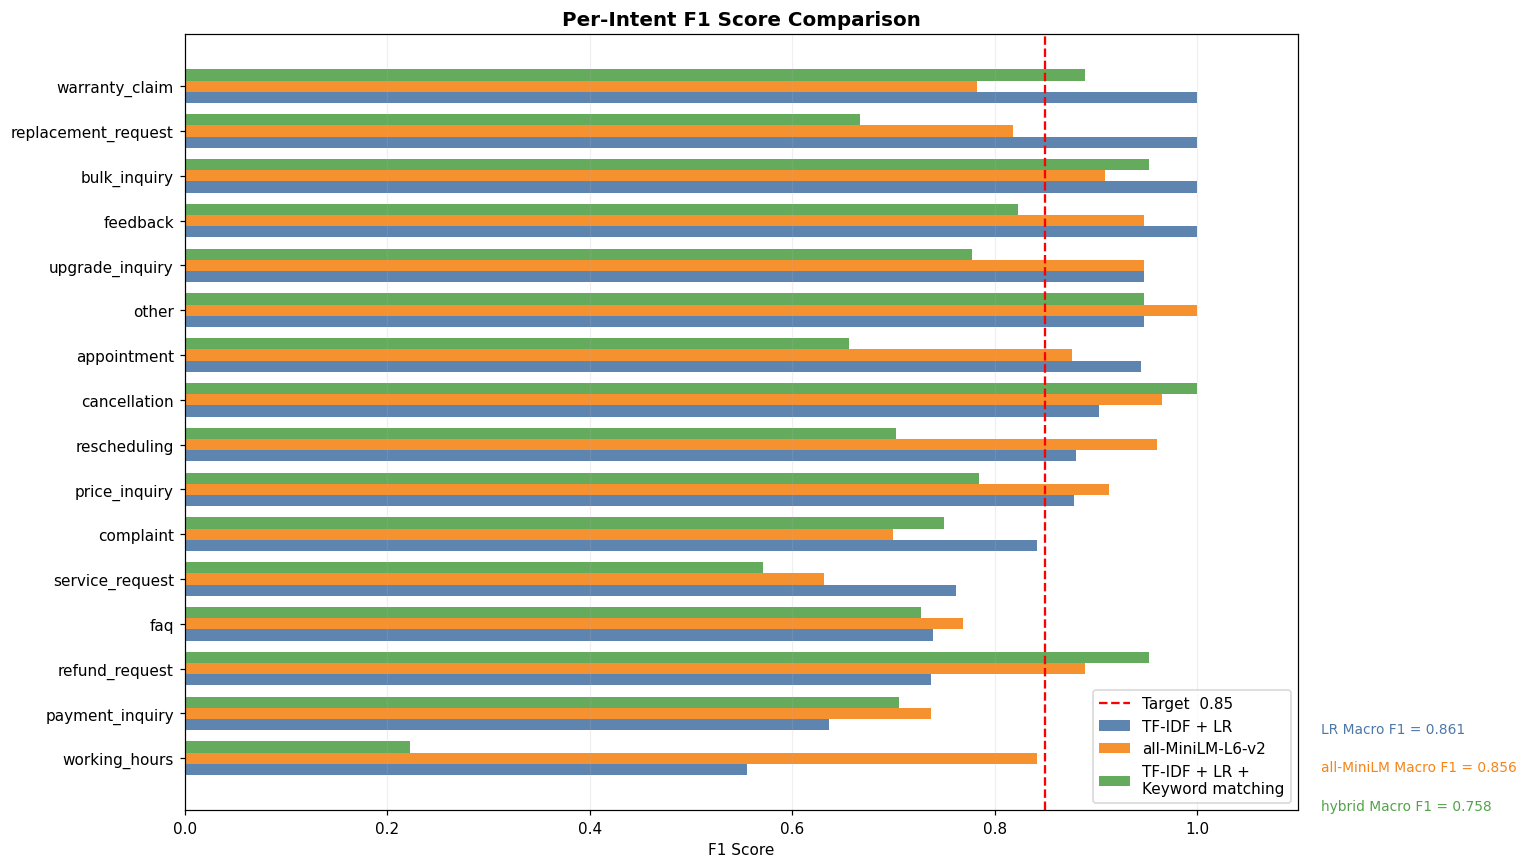

In [16]:
# ── Figure 2 — Per-Intent F1 Score Grouped Bar Chart ─────────────────────────
lr_f1_per     = f1_score(labels, y_preds_3,     labels=classes, average=None, zero_division=0)
bart_f1_per   = f1_score(labels, lm_preds,   labels=classes, average=None, zero_division=0)
hybrid_f1_per = f1_score(labels, hybrid_preds, labels=classes, average=None, zero_division=0)

f1_df = pd.DataFrame({
    "TF-IDF + LR":    lr_f1_per,
    "all-MiniLM-L6-v2": bart_f1_per,
    "hybrid":         hybrid_f1_per,
}, index=classes).sort_values("TF-IDF + LR", ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(f1_df))
w = 0.25
ax.barh(x - w, f1_df["TF-IDF + LR"],   w, label="TF-IDF + LR",   color="#4C78A8", alpha=0.9)
ax.barh(x,     f1_df["all-MiniLM-L6-v2"], w, label="all-MiniLM-L6-v2", color="#F58518", alpha=0.9)
ax.barh(x + w, f1_df["hybrid"],         w, label="TF-IDF + LR + \nKeyword matching", color="#54A24B", alpha=0.9)

ax.set_yticks(x);  ax.set_yticklabels(f1_df.index, fontsize=10)
ax.set_xlabel("F1 Score");  ax.set_xlim(0, 1.1)
ax.set_title("Per-Intent F1 Score Comparison", fontsize=13, fontweight="bold")
ax.axvline(0.85, color="red", linestyle="--", lw=1.5, label="Target  0.85")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2, axis="x")

lr_macro     = f1_score(labels, y_preds_3,     average="macro", zero_division=0)
bart_macro   = f1_score(labels, lm_preds,   average="macro", zero_division=0)
hybrid_macro = f1_score(labels, hybrid_preds, average="macro", zero_division=0)
for val, name, col, yoff in [
    (lr_macro,     "LR",     "#4C78A8", 0.10),
    (bart_macro,   "all-MiniLM",   "#F58518", 0.05),
    (hybrid_macro, "hybrid", "#54A24B", 0.00),
]:
    ax.text(1.02, yoff, f"{name} Macro F1 = {val:.3f}",
            color=col, fontsize=9, transform=ax.transAxes)

plt.tight_layout()
plt.show()

From above figure, we can see 11 out of 16 intents are correctly classifed by chosen TF-IDF+LR word + char hybrid version model.

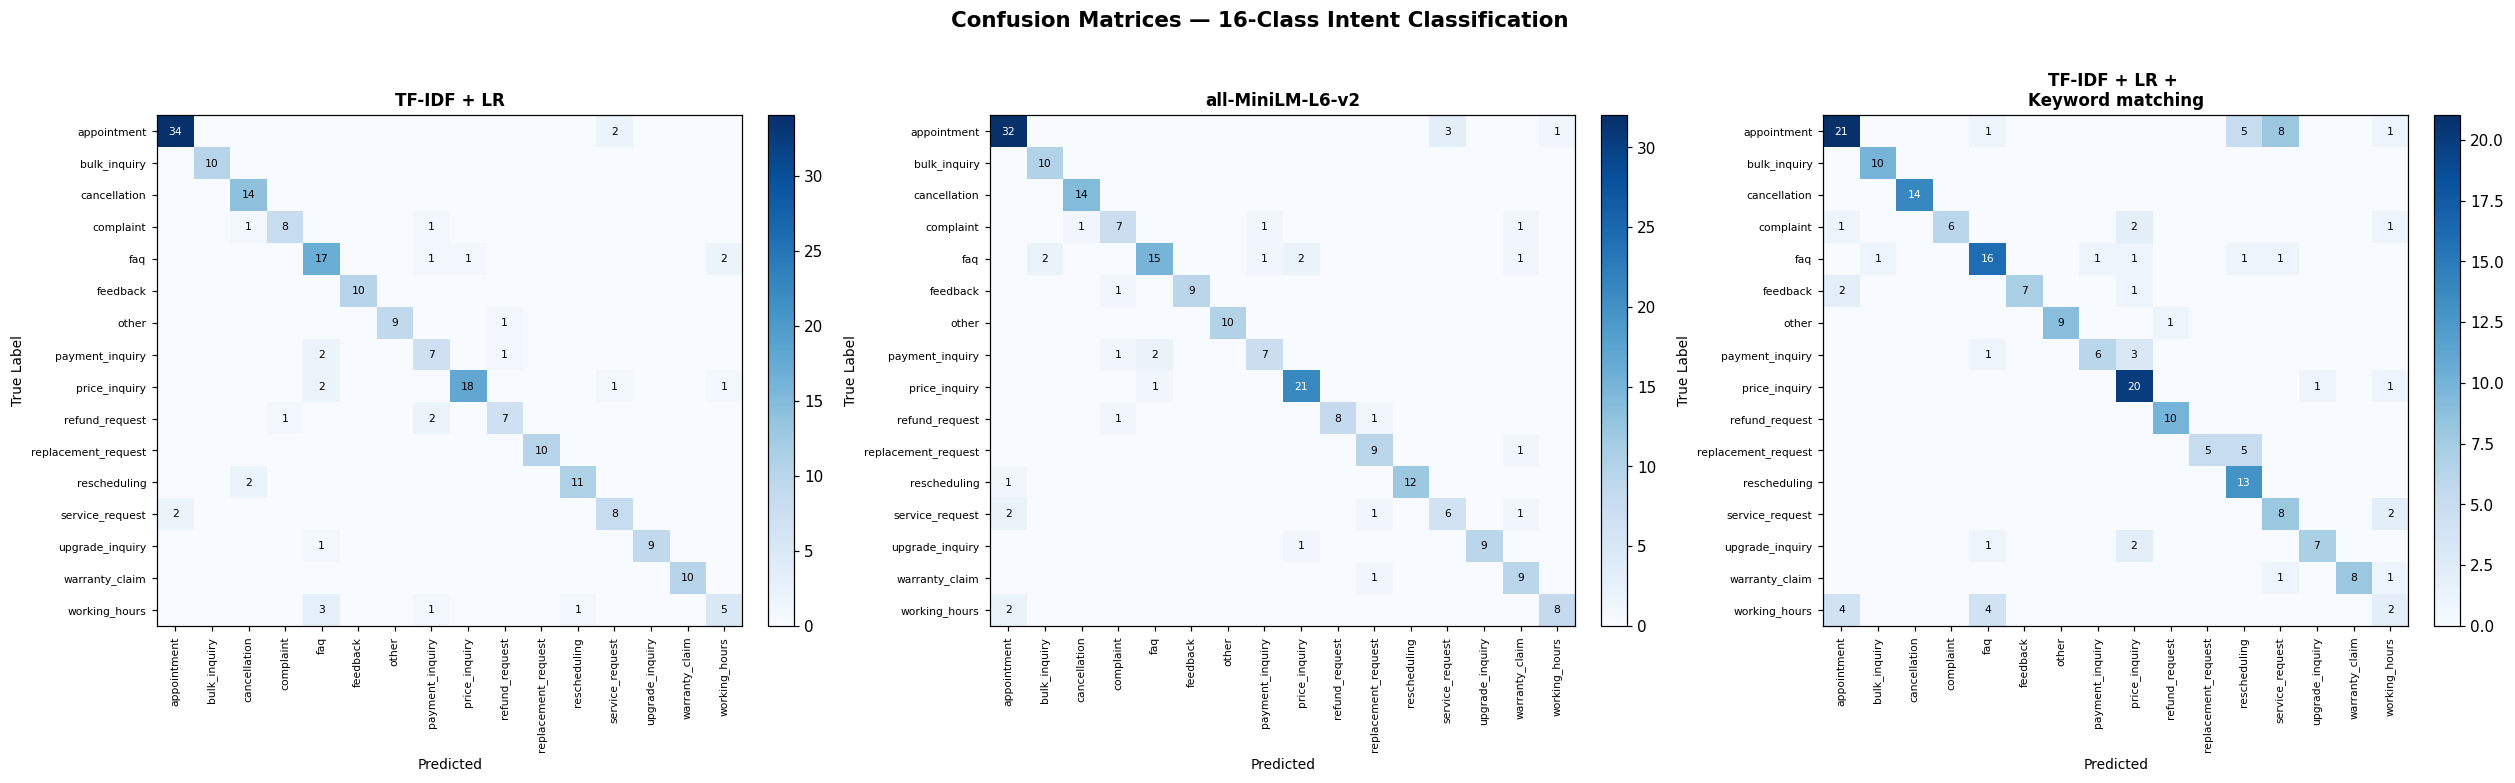

In [17]:
# Figure 3. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(23, 7))

def plot_cm(ax, y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred, labels=classes)
    maxv = cm.max() if cm.max() > 0 else 1
    im   = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(classes)));  ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=90, fontsize=7)
    ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel("Predicted", fontsize=9);  ax.set_ylabel("True Label", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for i in range(len(classes)):
        for j in range(len(classes)):
            v = cm[i, j]
            if v > 0:
                col = "white" if v > maxv * 0.6 else "black"
                ax.text(j, i, str(v), ha="center", va="center", fontsize=7, color=col)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_cm(axes[0], labels, y_preds_3,     "TF-IDF + LR")
plot_cm(axes[1], labels, lm_preds,   "all-MiniLM-L6-v2")
plot_cm(axes[2], labels, hybrid_preds, "TF-IDF + LR + \nKeyword matching")

plt.suptitle("Confusion Matrices — 16-Class Intent Classification",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Conclusions

| Finding | Detail |
|---------|--------|
| **TF-IDF+LR (word + char)** | Having the highest accuracy after fine-tuned. Adding more samples per rare intent would push CV accuracy significantly higher. |
| **all-MiniLM-L6-v2** | General-purpose; pergorm good as well. |
| **Hybrid (Production)** | Best real-world accuracy — keyword rules handle the high-volume majority at near-zero latency; TF-IDF+LR covers domain-specific patterns. |


Choose the TF-IDF+LR (word + char) hybrid version model as the production classifier.